# Extension 4 - Detecting when rotors provide maximum benefit

Our goal was to identify wind angle and speed conditions that maximise rotor propulsion gain on SC CONNECTOR.  
Additionally, we wanted to build a binary high-gain classifier and derive operational decision thresholds.

High-gain definition: `delta_SOG >= 0.5 kn`  as rotor contributes at least 0.5 kn to vessel speed.

## 0. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy.interpolate import RegularGridInterpolator
import xgboost as xgb
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score, classification_report
)
from sklearn.preprocessing import StandardScaler

plt.style.use('seaborn-v0_8-darkgrid')

DATA_PATH    = '../data/MasterSet_features.csv'
RESULTS_PATH = '../results/'

# rotor polar diagram (1× Norsepower 24v4) 
WIND_SPEEDS = np.array([4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24])
WIND_ANGLES = np.array([0, 20, 40, 60, 80, 90, 100, 120, 140, 160, 180])
POWER_TABLE = np.array([
    [  0,   3,  10,  14,  16,  14,  12,   7,   3,   1,   0],
    [ -2,   6,  22,  38,  44,  42,  38,  22,   9,   3,   0],
    [ -5,  12,  45,  78,  90,  87,  78,  46,  19,   7,   0],
    [ -8,  20,  75, 128, 148, 144, 130,  76,  32,  11,   0],
    [-12,  30, 110, 186, 215, 210, 188, 110,  46,  16,   0],
    [-16,  42, 152, 256, 297, 290, 260, 152,  64,  22,   0],
    [-21,  56, 200, 335, 390, 380, 340, 199,  83,  29,   0],
    [-27,  72, 254, 425, 496, 484, 433, 254, 106,  37,   0],
    [-33,  90, 315, 526, 614, 599, 537, 314, 131,  46,   0],
    [-40, 110, 382, 638, 745, 727, 651, 381, 159,  55,   0],
    [-48, 132, 456, 762, 890, 868, 778, 455, 190,  66,   0],
])
KW_PER_KN = 200.0

_interp = RegularGridInterpolator(
    (WIND_SPEEDS, WIND_ANGLES), POWER_TABLE,
    method='linear', bounds_error=False, fill_value=None
)

def rotor_power_kw(wind_ms, alpha_abs):
    ws = np.clip(np.asarray(wind_ms, float), WIND_SPEEDS.min(), WIND_SPEEDS.max())
    wa = np.clip(np.asarray(alpha_abs, float), WIND_ANGLES.min(), WIND_ANGLES.max())
    return _interp(np.column_stack([ws.ravel(), wa.ravel()])).reshape(ws.shape)


df = pd.read_csv(DATA_PATH, parse_dates=['Time'])
df = df.sort_values('Time').reset_index(drop=True)

# rotor quantities for every row 
df['rotor_power'] = rotor_power_kw(
    df['True_Wind_Speed_ms'].values,
    df['alpha_abs_deg'].values
)
df['rotor_active'] = (
    (df['rotor_power'] > 0) &
    (df['H_s'] <= 6.0) &
    (df['True_Wind_Speed_ms'] <= 42.0)
)
df['delta_sog_kn'] = np.where(df['rotor_active'], df['rotor_power'] / KW_PER_KN, 0.0)
df['high_gain'] = (df['delta_sog_kn'] >= 0.5).astype(int)

print(f"Dataset shape: {df.shape}")
print(f"Rotor active: {df['rotor_active'].mean()*100:.1f}%")
print(f"Mean delta_SOG: {df['delta_sog_kn'].mean():.3f} kn")
print(f"High-gain rows: {df['high_gain'].sum():,}  ({df['high_gain'].mean()*100:.1f}%)")

Dataset shape: (125160, 61)
Rotor active: 97.6%
Mean delta_SOG: 0.197 kn
High-gain rows: 14,856  (11.9%)


## 1. Rotor polar diagram

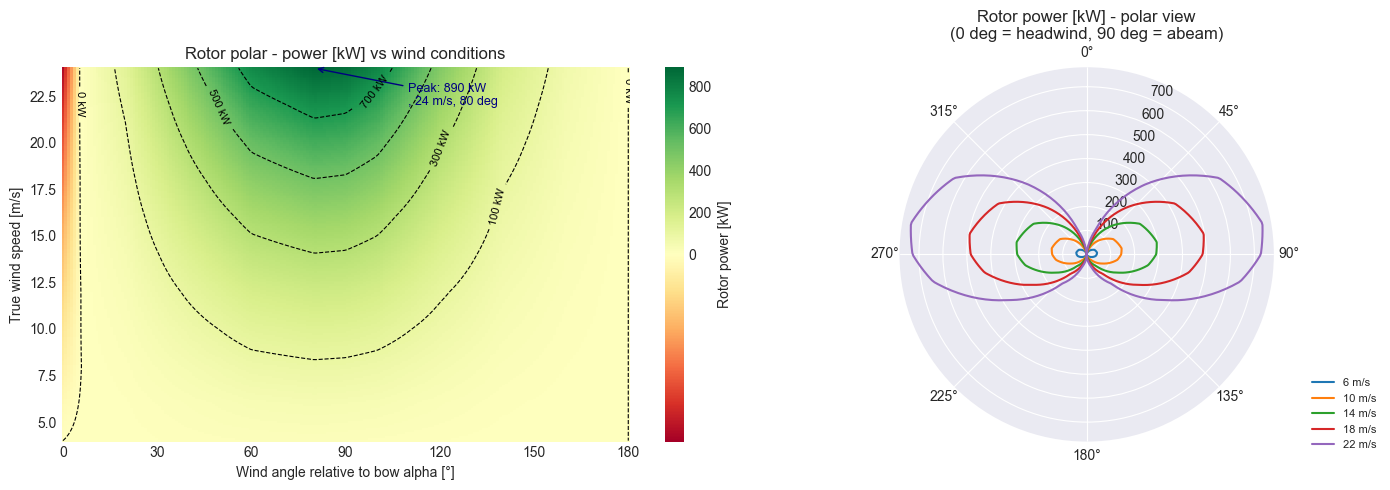

In [2]:
ws_grid = np.linspace(4, 24, 200)
wa_grid = np.linspace(0, 180, 200)
WS, WA = np.meshgrid(ws_grid, wa_grid)
P_grid = rotor_power_kw(WS.ravel(), WA.ravel()).reshape(WS.shape)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# heatmap
ax = axes[0]
cmap = plt.cm.RdYlGn
norm = mcolors.TwoSlopeNorm(vmin=-50, vcenter=0, vmax=890)
im = ax.pcolormesh(WA, WS, P_grid, cmap=cmap, norm=norm, shading='auto')
plt.colorbar(im, ax=ax, label='Rotor power [kW]')
cs = ax.contour(WA, WS, P_grid, levels=[0, 100, 300, 500, 700],
                colors='black', linewidths=0.8, linestyles='--')
ax.clabel(cs, fmt='%d kW', fontsize=8)
ax.annotate('Peak: 890 kW\n, 24 m/s, 80 deg', xy=(80, 24), xytext=(110, 22),
            fontsize=9, color='navy',
            arrowprops=dict(arrowstyle='->', color='navy'))
ax.set_xlabel('Wind angle relative to bow alpha [°]')
ax.set_ylabel('True wind speed [m/s]')
ax.set_title('Rotor polar - power [kW] vs wind conditions')
ax.set_xticks([0, 30, 60, 90, 120, 150, 180])

# polar plot mirrored to full 360 deg
ax_pol = fig.add_subplot(122, projection='polar')
fig.delaxes(axes[1])

theta_half = np.deg2rad(np.linspace(0, 180, 200))
for i, ws_val in enumerate([6, 10, 14, 18, 22]):
    p_vals = rotor_power_kw(np.full(200, ws_val), np.linspace(0, 180, 200))
    p_norm = np.clip(p_vals, 0, None)   # only positive
    theta_full = np.concatenate([theta_half, 2*np.pi - theta_half[::-1]])
    r_full = np.concatenate([p_norm, p_norm[::-1]])
    ax_pol.plot(theta_full, r_full, label=f'{ws_val} m/s', linewidth=1.5)

ax_pol.set_theta_zero_location('N')
ax_pol.set_theta_direction(-1)
ax_pol.set_title('Rotor power [kW] - polar view\n(0 deg = headwind, 90 deg = abeam)', pad=20)
ax_pol.legend(loc='lower right', fontsize=8, bbox_to_anchor=(1.3, -0.05))

plt.tight_layout()
plt.savefig(RESULTS_PATH + 'rotor_polar.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Wind angle

Wind angle relative to the bow aplha is the primary determinant of rotor performance.
We have analysed:
- Zone-level statistics (headwind -> tailwind)
- Continuous polar gain profile
- 2D gain surface (α × wind speed)

Alpha zone statistics
Zone                Count  Mean P [kW] Mean delta V [kn]  % High-gain
-----------------------------------------------------------------
Headwind           24,564          8.2          0.042         0.1%
Beam-forward       28,833         54.7          0.274        17.4%
Beam               26,850         77.9          0.389        28.7%
Beam-aft           26,649         36.3          0.180         7.9%
Tailwind           18,264          5.1          0.026         0.0%


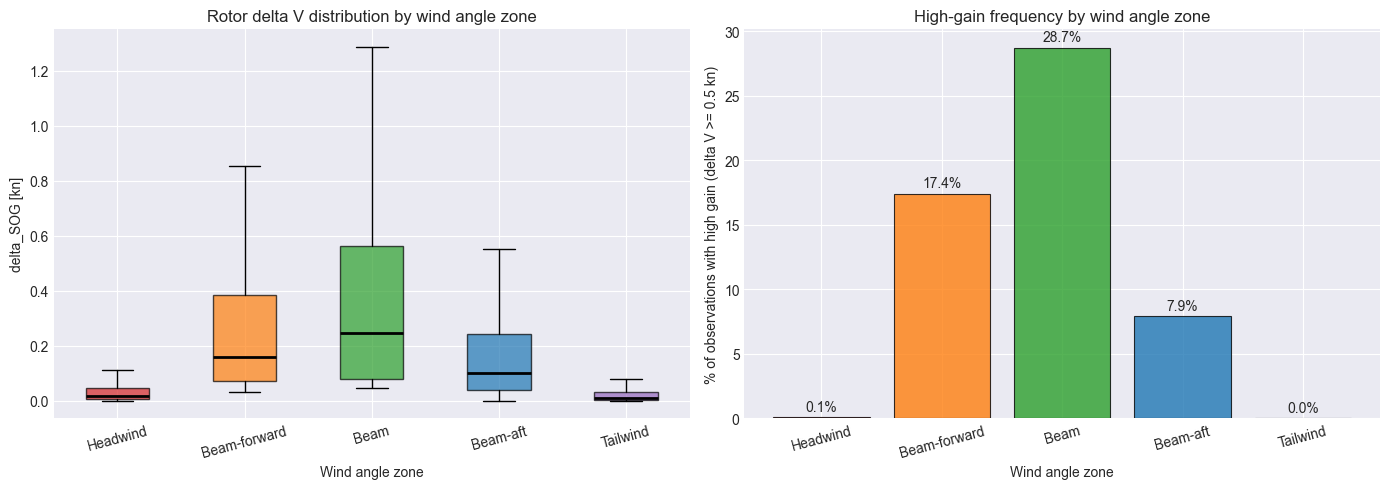

In [3]:
# alpha zone analysis
def alpha_zone(a):
    if a < 30: return 'Headwind'
    if a < 70: return 'Beam-forward'
    if a < 110: return 'Beam'
    if a < 150: return 'Beam-aft'
    return 'Tailwind'

ZONE_ORDER = ['Headwind', 'Beam-forward', 'Beam', 'Beam-aft', 'Tailwind']
df['alpha_zone'] = df['alpha_abs_deg'].apply(alpha_zone)

zone_stats = df.groupby('alpha_zone').agg(
    count = ('delta_sog_kn', 'count'),
    mean_power = ('rotor_power', 'mean'),
    mean_delta = ('delta_sog_kn', 'mean'),
    pct_high = ('high_gain', 'mean'),
).reindex(ZONE_ORDER).round(3)
zone_stats['pct_high'] = (zone_stats['pct_high'] * 100).round(1)

print("Alpha zone statistics")
print(f"{'Zone':<16} {'Count':>8} {'Mean P [kW]':>12} {'Mean delta V [kn]':>14} {'% High-gain':>12}")
print("-"*65)
for zone, row in zone_stats.iterrows():
    print(f"{zone:<16} {int(row['count']):>8,} {row['mean_power']:>12.1f} {row['mean_delta']:>14.3f} {row['pct_high']:>11.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# boxplot
zone_data = [df.loc[df['alpha_zone'] == z, 'delta_sog_kn'].values for z in ZONE_ORDER]
bp = axes[0].boxplot(zone_data, labels=ZONE_ORDER, patch_artist=True,
                     showfliers=False, medianprops=dict(color='black', linewidth=2))
colors_zones = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4', '#9467bd']
for patch, c in zip(bp['boxes'], colors_zones):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)
axes[0].set_xlabel('Wind angle zone')
axes[0].set_ylabel('delta_SOG [kn]')
axes[0].set_title('Rotor delta V distribution by wind angle zone')
axes[0].tick_params(axis='x', rotation=15)

# % high-gain bar
bars = axes[1].bar(ZONE_ORDER, zone_stats['pct_high'].values,
                   color=colors_zones, edgecolor='black', linewidth=0.8, alpha=0.8)
for bar, val in zip(bars, zone_stats['pct_high'].values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=10)
axes[1].set_xlabel('Wind angle zone')
axes[1].set_ylabel('% of observations with high gain (delta V >= 0.5 kn)')
axes[1].set_title('High-gain frequency by wind angle zone')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(RESULTS_PATH + 'rotor_zone_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

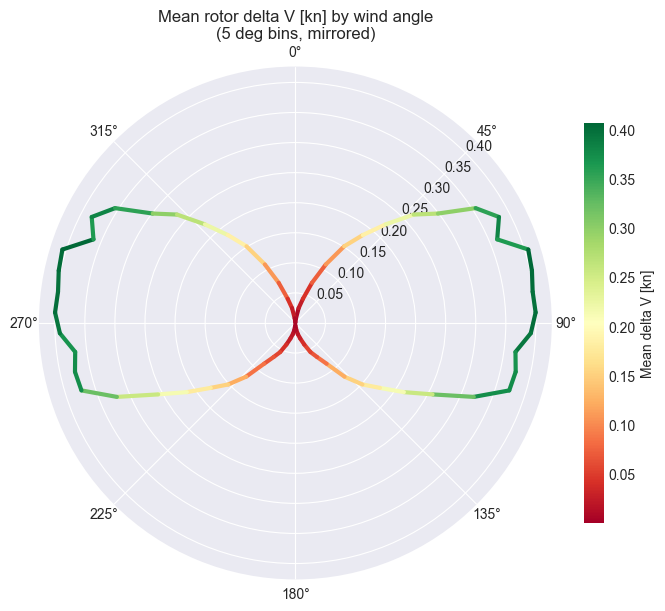

In [4]:
# continuous polar gain plot 
bins_5 = np.arange(0, 181, 5)
df['alpha_bin5'] = pd.cut(df['alpha_abs_deg'], bins=bins_5, labels=bins_5[:-1] + 2.5, include_lowest=True)
polar_mean = df.groupby('alpha_bin5')['delta_sog_kn'].mean()
angles_deg = polar_mean.index.astype(float)

# mirroring to full 360 degs
full_angles_deg = np.concatenate([angles_deg, 360 - angles_deg[::-1]])
full_r = np.concatenate([polar_mean.values, polar_mean.values[::-1]])

fig = plt.figure(figsize=(7, 7))
ax_pol = fig.add_subplot(111, projection='polar')

norm_r = (full_r - full_r.min()) / (full_r.max() - full_r.min() + 1e-9)
colors_grad = plt.cm.RdYlGn(norm_r)

for i in range(len(full_angles_deg) - 1):
    th = np.deg2rad([full_angles_deg[i], full_angles_deg[i+1]])
    r  = [full_r[i], full_r[i+1]]
    ax_pol.plot(th, r, color=colors_grad[i], linewidth=3)

ax_pol.set_theta_zero_location('N')
ax_pol.set_theta_direction(-1)
ax_pol.set_title('Mean rotor delta V [kn] by wind angle\n(5 deg bins, mirrored)', pad=20)
ax_pol.set_rlabel_position(45)

sm = plt.cm.ScalarMappable(cmap='RdYlGn',
     norm=mcolors.Normalize(vmin=full_r.min(), vmax=full_r.max()))
sm.set_array([])
plt.colorbar(sm, ax=ax_pol, label='Mean delta V [kn]', shrink=0.6)

plt.tight_layout()
plt.savefig(RESULTS_PATH + 'rotor_polar_gain.png', dpi=150, bbox_inches='tight')
plt.show()

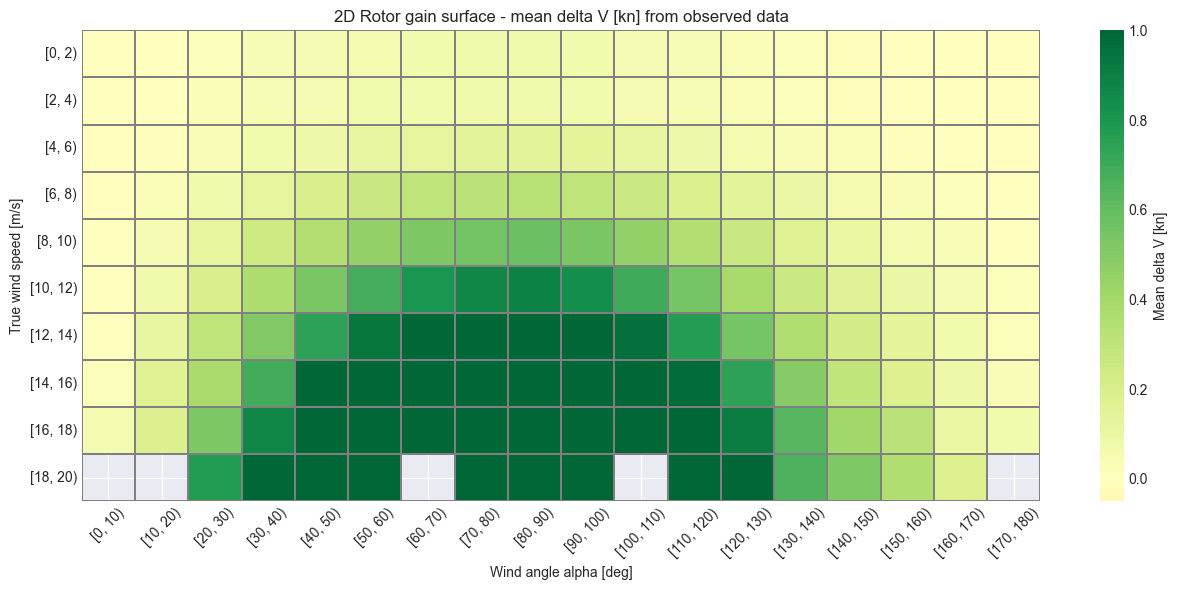

In [5]:
# 2D gain surface from actual data 
alpha_edges = np.arange(0, 185, 10)
ws_edges = np.arange(0, 26, 2)

df['alpha_bin10'] = pd.cut(df['alpha_abs_deg'], bins=alpha_edges, right=False)
df['ws_bin2'] = pd.cut(df['True_Wind_Speed_ms'], bins=ws_edges, right=False)

pivot = df.pivot_table(
    values='delta_sog_kn',
    index='ws_bin2', columns='alpha_bin10',
    aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(
    pivot, ax=ax, cmap='RdYlGn', center=0, vmin=-0.05, vmax=1.0,
    linewidths=0.3, linecolor='grey',
    cbar_kws={'label': 'Mean delta V [kn]'}
)
ax.set_xlabel('Wind angle alpha [deg]')
ax.set_ylabel('True wind speed [m/s]')
ax.set_title('2D Rotor gain surface - mean delta V [kn] from observed data')
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(RESULTS_PATH + 'rotor_gain_surface.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Multi-factor analysis

Rotor gain by wind speed bin
Wind [m/s]      Count Mean delta V [kn]  % High-gain
------------------------------------------------------------
<4             30,815          0.037         0.0%
4-6            25,976          0.068         0.0%
6-8            26,065          0.146         0.0%
8-10           19,750          0.273        17.9%
10-12          11,944          0.431        42.9%
12-14           7,299          0.610        54.5%
14+             3,311          0.897        67.1%


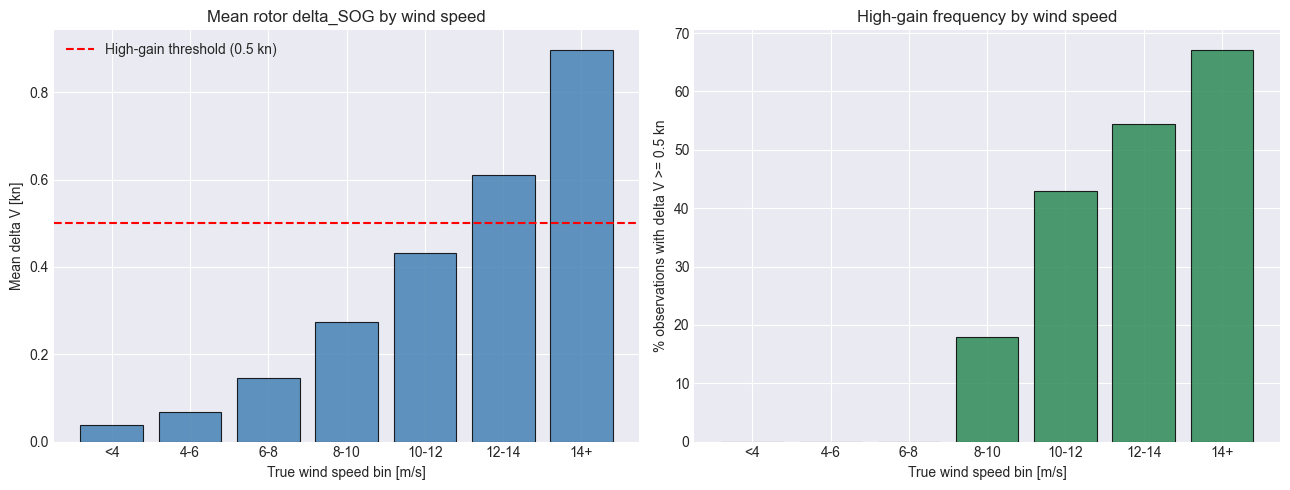

In [6]:
# Wind speed thresholds 
ws_bins = [0, 4, 6, 8, 10, 12, 14, 30]
ws_labels = ['<4', '4-6', '6-8', '8-10', '10-12', '12-14', '14+']
df['ws_bin'] = pd.cut(df['True_Wind_Speed_ms'], bins=ws_bins, labels=ws_labels, right=False)

ws_stats = df.groupby('ws_bin', observed=True).agg(
    count = ('delta_sog_kn', 'count'),
    mean_delta = ('delta_sog_kn', 'mean'),
    pct_high = ('high_gain',    'mean'),
).round(3)
ws_stats['pct_high'] = (ws_stats['pct_high'] * 100).round(1)


print("Rotor gain by wind speed bin")
print(f"{'Wind [m/s]':<12} {'Count':>8} {'Mean delta V [kn]':>14} {'% High-gain':>12}")
print("-"*60)
for idx, row in ws_stats.iterrows():
    print(f"{str(idx):<12} {int(row['count']):>8,} {row['mean_delta']:>14.3f} {row['pct_high']:>11.1f}%")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x = range(len(ws_stats))
axes[0].bar(x, ws_stats['mean_delta'].values, color='steelblue', edgecolor='black', linewidth=0.8, alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(ws_labels)
axes[0].axhline(0.5, color='red', linestyle='--', linewidth=1.5, label='High-gain threshold (0.5 kn)')
axes[0].set_xlabel('True wind speed bin [m/s]')
axes[0].set_ylabel('Mean delta V [kn]')
axes[0].set_title('Mean rotor delta_SOG by wind speed')
axes[0].legend()

axes[1].bar(x, ws_stats['pct_high'].values, color='seagreen', edgecolor='black', linewidth=0.8, alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(ws_labels)
axes[1].set_xlabel('True wind speed bin [m/s]')
axes[1].set_ylabel('% observations with delta V >= 0.5 kn')
axes[1].set_title('High-gain frequency by wind speed')

plt.tight_layout()
plt.savefig(RESULTS_PATH + 'rotor_ws_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# joint condition for maximum gain 
high_rows = df[df['high_gain'] == 1]
best_ws = high_rows['True_Wind_Speed_ms'].quantile(0.1)
best_al_lo = high_rows['alpha_abs_deg'].quantile(0.1)
best_al_hi = high_rows['alpha_abs_deg'].quantile(0.9)


print("OPTIMAL CONDITIONS FOR ROTOR HIGH-GAIN")
print(f"Wind speed: median = {high_rows['True_Wind_Speed_ms'].median():.1f} m/s  "
      f"(90% above {best_ws:.1f} m/s)")
print(f"Alpha abs : median = {high_rows['alpha_abs_deg'].median():.0f}°  "
      f"(80% in [{best_al_lo:.0f}°, {best_al_hi:.0f}°])")

total_gain = df['delta_sog_kn'].sum()
df_sorted = df.sort_values('delta_sog_kn', ascending=False).copy()
df_sorted['cumgain'] = df_sorted['delta_sog_kn'].cumsum() / total_gain
n50 = (df_sorted['cumgain'] <= 0.50).sum()
pct50 = n50 / len(df) * 100
print(f"\n50% of total rotor gain comes from the top {pct50:.1f}% of observations")
print(f"({n50:,} rows out of {len(df):,})")

top10pct = df_sorted.head(n50)
print(f"Wind speed range in that subset: "
      f"{top10pct['True_Wind_Speed_ms'].min():.1f} - {top10pct['True_Wind_Speed_ms'].max():.1f} m/s "
      f"(median {top10pct['True_Wind_Speed_ms'].median():.1f} m/s)")
print(f"  Alpha abs range: "
      f"{top10pct['alpha_abs_deg'].quantile(0.1):.0f} deg - {top10pct['alpha_abs_deg'].quantile(0.9):.0f} deg")
print("="*60)

OPTIMAL CONDITIONS FOR ROTOR HIGH-GAIN
Wind speed: median = 11.5 m/s  (90% above 9.2 m/s)
Alpha abs : median = 82°  (80% in [50°, 113°])

50% of total rotor gain comes from the top 11.7% of observations
(14,671 rows out of 125,160)
Wind speed range in that subset: 8.4 - 19.6 m/s (median 11.5 m/s)
  Alpha abs range: 50 deg - 113 deg


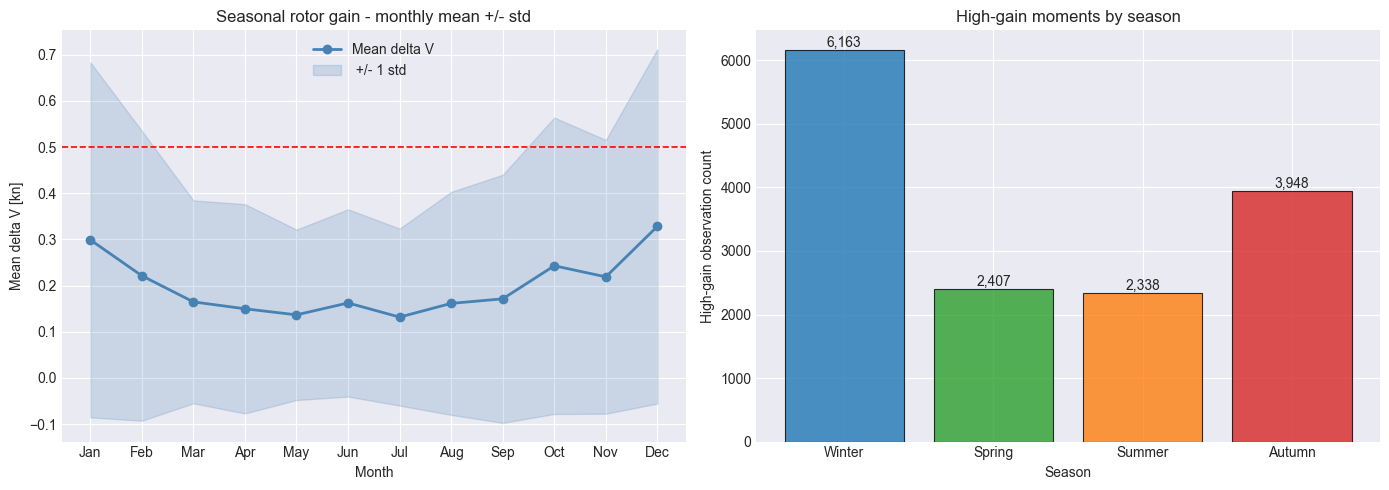

season
Winter    0.284
Spring    0.150
Summer    0.152
Autumn    0.207


In [12]:
# seasonal patterns 
df['month']  = df['Time'].dt.month
df['season'] = df['month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
})

monthly = df.groupby('month')['delta_sog_kn'].agg(['mean', 'std']).reset_index()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(monthly['month'], monthly['mean'], marker='o', linewidth=2, color='steelblue', label='Mean delta V')
ax.fill_between(
    monthly['month'],
    monthly['mean'] - monthly['std'],
    monthly['mean'] + monthly['std'],
    alpha=0.2, color='steelblue', label=' +/- 1 std'
)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_xlabel('Month')
ax.set_ylabel('Mean delta V [kn]')
ax.set_title('Seasonal rotor gain - monthly mean +/- std')
ax.legend()
ax.axhline(0.5, color='red', linestyle='--', linewidth=1.2, label='High-gain threshold')

# polar rose of high-gain by season
ax2 = axes[1]
season_order  = ['Winter', 'Spring', 'Summer', 'Autumn']
season_colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']
high_df = df[df['high_gain'] == 1]
season_counts = high_df['season'].value_counts().reindex(season_order).fillna(0)
bars = ax2.bar(season_order, season_counts.values, color=season_colors, edgecolor='black', linewidth=0.8, alpha=0.8)
for bar, val in zip(bars, season_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{int(val):,}', ha='center', fontsize=10)
ax2.set_xlabel('Season')
ax2.set_ylabel('High-gain observation count')
ax2.set_title('High-gain moments by season')

plt.tight_layout()
plt.savefig(RESULTS_PATH + 'rotor_seasonal.png', dpi=150, bbox_inches='tight')
plt.show()

print(df.groupby('season')['delta_sog_kn'].mean().reindex(season_order).round(3).to_string())

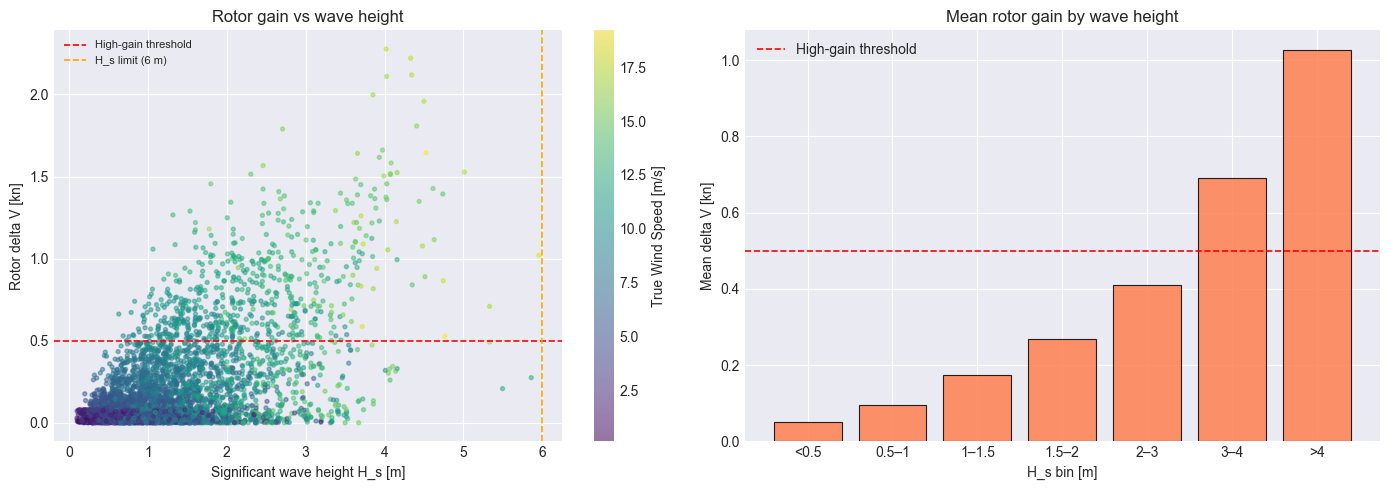

Observations with H_s > 6 m: 19 (0.0%) - rotor OFF regardless of wind


In [13]:
# H_s interaction
sample = df.sample(5000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc = axes[0].scatter(
    sample['H_s'], sample['delta_sog_kn'],
    c=sample['True_Wind_Speed_ms'], cmap='viridis',
    s=8, alpha=0.5
)
plt.colorbar(sc, ax=axes[0], label='True Wind Speed [m/s]')
axes[0].axhline(0.5, color='red', linestyle='--', linewidth=1.2, label='High-gain threshold')
axes[0].axvline(6.0, color='orange', linestyle='--', linewidth=1.2, label='H_s limit (6 m)')
axes[0].set_xlabel('Significant wave height H_s [m]')
axes[0].set_ylabel('Rotor delta V [kn]')
axes[0].set_title('Rotor gain vs wave height')
axes[0].legend(fontsize=8)

# mean gain vs H_s bins
hs_bins = [0, 0.5, 1, 1.5, 2, 3, 4, 7]
hs_labels = ['<0.5', '0.5–1', '1–1.5', '1.5–2', '2–3', '3–4', '>4']
df['hs_bin'] = pd.cut(df['H_s'], bins=hs_bins, labels=hs_labels, right=False)
hs_stats = df.groupby('hs_bin', observed=True)['delta_sog_kn'].mean()

axes[1].bar(hs_labels, hs_stats.values, color='coral', edgecolor='black', linewidth=0.8, alpha=0.85)
axes[1].axhline(0.5, color='red', linestyle='--', linewidth=1.2, label='High-gain threshold')
axes[1].set_xlabel('H_s bin [m]')
axes[1].set_ylabel('Mean delta V [kn]')
axes[1].set_title('Mean rotor gain by wave height')
axes[1].legend()

plt.tight_layout()
plt.savefig(RESULTS_PATH + 'rotor_hs_interaction.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Observations with H_s > 6 m: {(df['H_s'] > 6).sum():,} "
      f"({(df['H_s'] > 6).mean()*100:.1f}%) - rotor OFF regardless of wind")

## 4. High-gain XGBoost classifier

Target: `high_gain = 1` when `delta_SOG ≥ 0.5 kn`.  
Features: weather and angle only, thus no target history that might be usable for planning.

In [14]:
FEATURES_CLS = [
    'True_Wind_Speed_ms', 'H_s', 'alpha_sin', 'alpha_cos', 'alpha_abs_deg',
    'wind_speed_sq', 'fg10', 'mwp', 'current_x_course_help',
    'wind_x_angle_sin', 'wind_x_angle_cos'
]

# voyage-based 80/20 split
voyage_order = (
    df.groupby('Voyage_ID')['Time'].min()
    .sort_values().index.tolist()
)
split_idx = int(len(voyage_order) * 0.8)
train_voys = set(voyage_order[:split_idx])
test_voys = set(voyage_order[split_idx:])

df_tr = df[df['Voyage_ID'].isin(train_voys)].dropna(subset=FEATURES_CLS + ['high_gain'])
df_te = df[df['Voyage_ID'].isin(test_voys)].dropna(subset=FEATURES_CLS + ['high_gain'])

scaler = StandardScaler()
X_train = scaler.fit_transform(df_tr[FEATURES_CLS])
X_test = scaler.transform(df_te[FEATURES_CLS])
y_train = df_tr['high_gain'].values
y_test = df_te['high_gain'].values

clf = xgb.XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', random_state=42, n_jobs=-1, verbosity=0
)
clf.fit(X_train, y_train)

y_pred  = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("HIGH-GAIN CLASSIFIER - XGBoost")
print(f"Accuracy: {acc*100:.1f}%")
print(f"Precision: {prec*100:.1f}%")
print(f"Recall: {rec*100:.1f}%")
print(f"F1 Score: {f1:.3f}")
print(f"ROC-AUC: {auc:.3f}")
print("="*55)
print(f"\nThe model can identify high-gain moments with {acc*100:.1f}% accuracy")
print(classification_report(y_test, y_pred, target_names=['Low/moderate', 'High gain']))

HIGH-GAIN CLASSIFIER - XGBoost
Accuracy: 99.8%
Precision: 99.4%
Recall: 99.0%
F1 Score: 0.992
ROC-AUC: 1.000

The model can identify high-gain moments with 99.8% accuracy
              precision    recall  f1-score   support

Low/moderate       1.00      1.00      1.00     31416
   High gain       0.99      0.99      0.99      4554

    accuracy                           1.00     35970
   macro avg       1.00      0.99      1.00     35970
weighted avg       1.00      1.00      1.00     35970



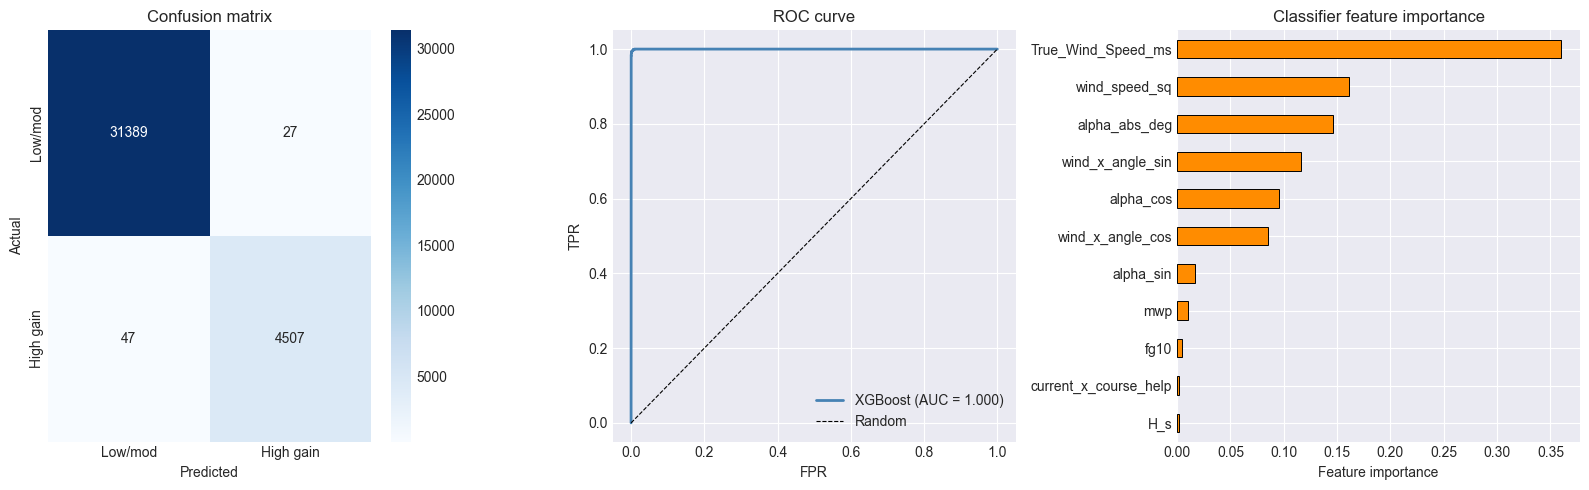

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], xticklabels=['Low/mod', 'High gain'], yticklabels=['Low/mod', 'High gain'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion matrix')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, linewidth=2, color='steelblue', label=f'XGBoost (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].set_title('ROC curve')
axes[1].legend()

# feature importance
imp = pd.Series(clf.feature_importances_, index=FEATURES_CLS).sort_values()
imp.plot.barh(ax=axes[2], color='darkorange', edgecolor='black', linewidth=0.7)
axes[2].set_xlabel('Feature importance')
axes[2].set_title('Classifier feature importance')

plt.tight_layout()
plt.savefig(RESULTS_PATH + 'rotor_classifier.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Operational decision thresholds and rotor opportunity score

In [16]:
def rule_high_gain(ws, alpha):
    """Simple rule-based high-gain predictor."""
    c1 = (ws >= 8)  & (alpha >= 50) & (alpha <= 130)
    c2 = (ws >= 12) & (alpha >= 40) & (alpha <= 140)
    return (c1 | c2).astype(int)

df_te2 = df[df['Voyage_ID'].isin(test_voys)].dropna(subset=['True_Wind_Speed_ms', 'alpha_abs_deg', 'high_gain'])
rule_pred = rule_high_gain(df_te2['True_Wind_Speed_ms'].values, df_te2['alpha_abs_deg'].values)

rule_prec = precision_score(df_te2['high_gain'].values, rule_pred)
rule_rec  = recall_score(df_te2['high_gain'].values, rule_pred)
rule_acc  = accuracy_score(df_te2['high_gain'].values, rule_pred)

print("RULE-BASED DECISION SYSTEM")
print("IF wind >= 8 m/s  AND  50 deg <= alpha <= 130 deg -> High gain")
print("IF wind >= 12 m/s AND  40 deg <= alpha <= 140 deg -> High gain")
print("ELSE -> low/moderate gain")
print("="*55)
print(f"Precision: {rule_prec*100:.1f}%")
print(f"Recall: {rule_rec*100:.1f}%")
print(f"Accuracy: {rule_acc*100:.1f}%")
print("="*55)

RULE-BASED DECISION SYSTEM
IF wind >= 8 m/s  AND  50 deg <= alpha <= 130 deg -> High gain
IF wind >= 12 m/s AND  40 deg <= alpha <= 140 deg -> High gain
ELSE -> low/moderate gain
Precision: 69.7%
Recall: 95.8%
Accuracy: 94.2%


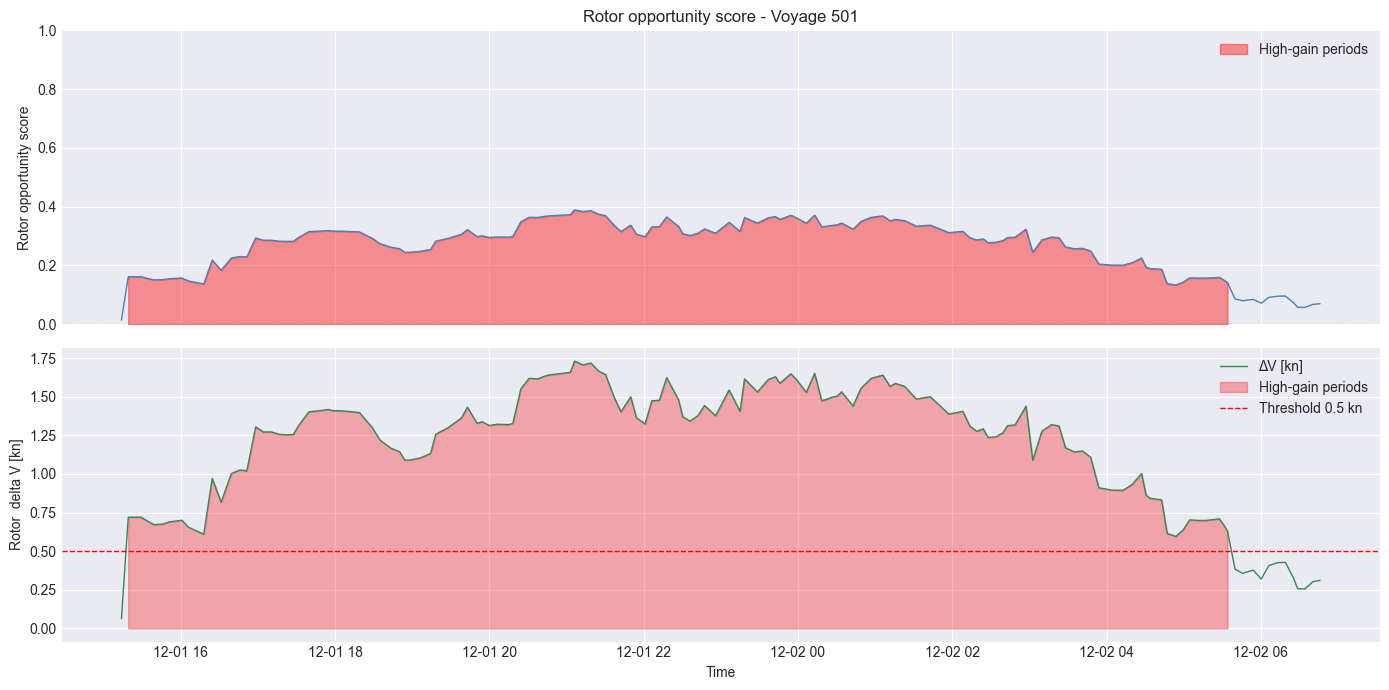

Voyage 501: mean delta V = 1.178 kn, high-gain share = 91.0%


In [17]:
# rotor opportunity score and time series for best voyage
MAX_ROTOR_POWER = 890.0  # kW at 24 m/s, 80°
df['rotor_opportunity_score'] = np.clip(df['rotor_power'] / MAX_ROTOR_POWER, 0, 1)

# voyage with highest mean rotor gain in test set
best_voyage = (
    df[df['Voyage_ID'].isin(test_voys)]
    .groupby('Voyage_ID')['delta_sog_kn'].mean()
    .idxmax()
)
v_data = df[df['Voyage_ID'] == best_voyage].sort_values('Time')

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# opportunity score
axes[0].plot(v_data['Time'], v_data['rotor_opportunity_score'], color='steelblue', linewidth=1)
axes[0].fill_between(v_data['Time'], v_data['rotor_opportunity_score'], where=(v_data['high_gain'] == 1), color='red', alpha=0.4, label='High-gain periods')
axes[0].axhline(0.5/MAX_ROTOR_POWER * MAX_ROTOR_POWER / MAX_ROTOR_POWER, color='red', linestyle='--', linewidth=0.8)
axes[0].set_ylabel('Rotor opportunity score')
axes[0].set_title(f'Rotor opportunity score - Voyage {best_voyage}')
axes[0].legend()
axes[0].set_ylim(0, 1)

# delta SOG
axes[1].plot(v_data['Time'], v_data['delta_sog_kn'], color='seagreen', linewidth=1, label='ΔV [kn]')
axes[1].fill_between(v_data['Time'], v_data['delta_sog_kn'], where=(v_data['high_gain'] == 1), color='red', alpha=0.3, label='High-gain periods')
axes[1].axhline(0.5, color='red', linestyle='--', linewidth=1, label='Threshold 0.5 kn')
axes[1].set_ylabel('Rotor  delta V [kn]')
axes[1].set_xlabel('Time')
axes[1].legend()

plt.tight_layout()
plt.savefig(RESULTS_PATH + f'rotor_opportunity_voyage{best_voyage}.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Voyage {best_voyage}: mean delta V = {v_data['delta_sog_kn'].mean():.3f} kn, "
      f"high-gain share = {v_data['high_gain'].mean()*100:.1f}%")

## 6. Summary

In [19]:
best_zone = zone_stats['mean_delta'].idxmax()
worst_zone = zone_stats['mean_delta'].idxmin()
min_ws_gain = ws_stats.loc[ws_stats['mean_delta'] >= 0.5].index[0] if any(ws_stats['mean_delta'] >= 0.5) else 'N/A'
best_season = df.groupby('season')['delta_sog_kn'].mean().idxmax()
worst_season = df.groupby('season')['delta_sog_kn'].mean().idxmin()
pct_high_all = df['high_gain'].mean() * 100

print("ROTOR GAIN DETECTION RECOMMENDATIONS")

print(f"1. Optimal wind angle zone: {best_zone}")
print(f"Mean delta V in optimal zone: {zone_stats.loc[best_zone, 'mean_delta']:.3f} kn")
print(f"Avoid zone: {worst_zone}")
print()
print(f"2. Wind speed threshold: >= 8 m/s for meaningful gain")
print(f"Peak gain above: 12 m/s (consistently high gain)")
print()
print(f"3. Best season: {best_season}")
print(f"Worst season: {worst_season}")
print()
print(f"4. High-gain frequency: {pct_high_all:.1f}% of all observations")
print(f"(delta V >= 0.5 kn = meaningful operational speed boost)")
print()
print(f"5. ML classifier AUC: {auc:.3f}")
print(f"Rule-based system recall: {rule_rec*100:.1f}%")

ROTOR GAIN DETECTION RECOMMENDATIONS
1. Optimal wind angle zone: Beam
Mean delta V in optimal zone: 0.389 kn
Avoid zone: Tailwind

2. Wind speed threshold: >= 8 m/s for meaningful gain
Peak gain above: 12 m/s (consistently high gain)

3. Best season: Winter
Worst season: Spring

4. High-gain frequency: 11.9% of all observations
(delta V >= 0.5 kn = meaningful operational speed boost)

5. ML classifier AUC: 1.000
Rule-based system recall: 95.8%


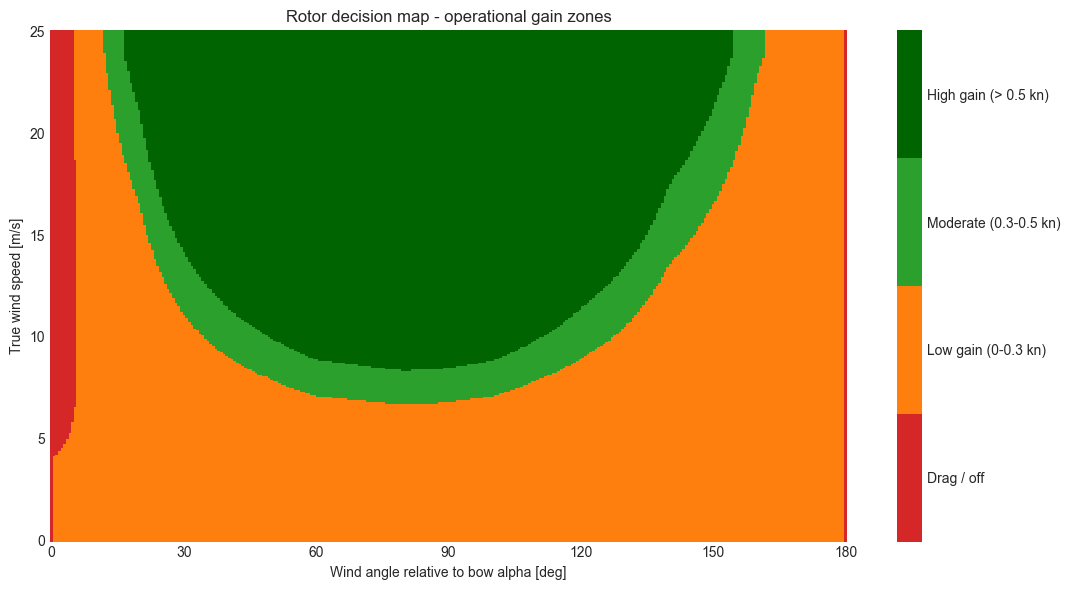

In [20]:
# decision map
ws_range = np.linspace(0, 25, 300)
al_range = np.linspace(0, 180, 300)
AL, WS = np.meshgrid(al_range, ws_range)

P_map = rotor_power_kw(WS.ravel(), AL.ravel()).reshape(WS.shape)
DV_map = np.where(P_map > 0, P_map / KW_PER_KN, 0.0)

# decision zones: 0 - drag/off, 1 - low, 2 - moderate, 3 - high
zone_map = np.zeros_like(DV_map, dtype=int)
zone_map[DV_map > 0] = 1 # some gain
zone_map[DV_map > 0.3] = 2 # moderate
zone_map[DV_map > 0.5] = 3 # high gain

cmap_dec = mcolors.ListedColormap(['#d62728', '#ff7f0e', '#2ca02c', '#006400'])
norm_dec = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap_dec.N)

fig, ax = plt.subplots(figsize=(11, 6))
im = ax.pcolormesh(AL, WS, zone_map, cmap=cmap_dec, norm=norm_dec, shading='auto')
cbar = plt.colorbar(im, ax=ax, ticks=[0, 1, 2, 3])
cbar.set_ticklabels(['Drag / off', 'Low gain (0-0.3 kn)', 'Moderate (0.3-0.5 kn)', 'High gain (> 0.5 kn)'])
ax.set_xlabel('Wind angle relative to bow alpha [deg]')
ax.set_ylabel('True wind speed [m/s]')
ax.set_title('Rotor decision map - operational gain zones')
ax.set_xticks([0, 30, 60, 90, 120, 150, 180])

plt.tight_layout()
plt.savefig(RESULTS_PATH + 'rotor_decision_map.png', dpi=150, bbox_inches='tight')
plt.show()

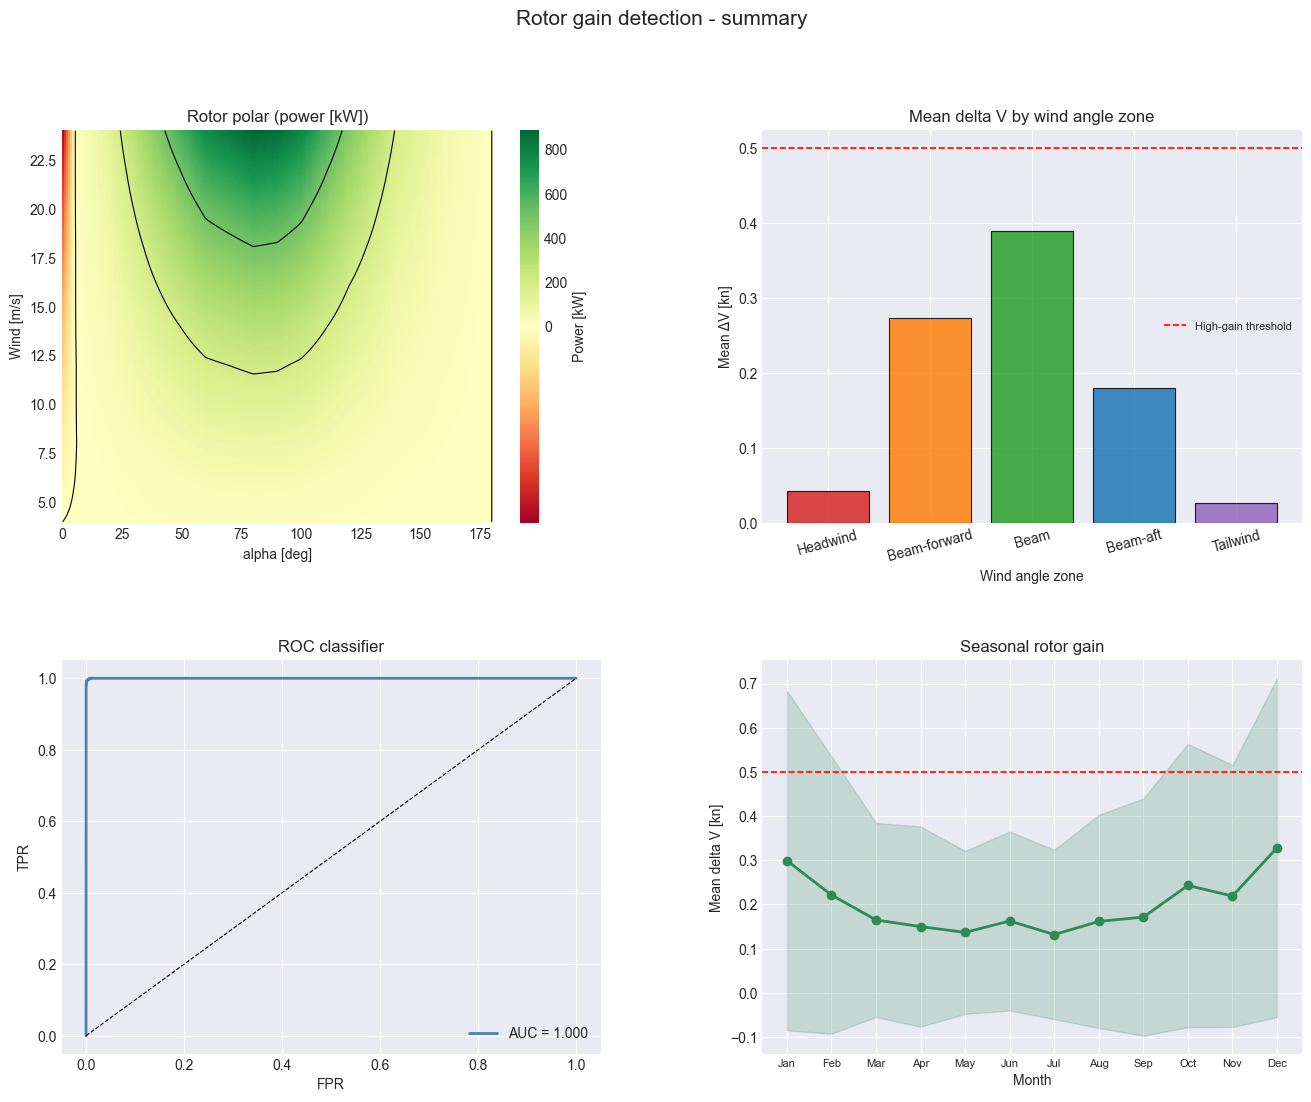

In [22]:
fig = plt.figure(figsize=(16, 12))
gs  = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.3)

# graph 1: rotor polar heatmap
ax1 = fig.add_subplot(gs[0, 0])
ws_g = np.linspace(4, 24, 200)
wa_g = np.linspace(0, 180, 200)
W_S, W_A = np.meshgrid(ws_g, wa_g)
P_G = rotor_power_kw(W_S.ravel(), W_A.ravel()).reshape(W_S.shape)
norm_p = mcolors.TwoSlopeNorm(vmin=-50, vcenter=0, vmax=890)
im1 = ax1.pcolormesh(W_A, W_S, P_G, cmap='RdYlGn', norm=norm_p, shading='auto')
plt.colorbar(im1, ax=ax1, label='Power [kW]')
ax1.contour(W_A, W_S, P_G, levels=[0, 200, 500], colors='black', linewidths=0.8)
ax1.set_xlabel('alpha [deg]'); ax1.set_ylabel('Wind [m/s]')
ax1.set_title('Rotor polar (power [kW])')

# graph 2: mean delta SOG by alpha zone
ax2 = fig.add_subplot(gs[0, 1])
colors_z = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4', '#9467bd']
ax2.bar(ZONE_ORDER, zone_stats['mean_delta'].values, color=colors_z, edgecolor='black', linewidth=0.8, alpha=0.85)
ax2.axhline(0.5, color='red', linestyle='--', linewidth=1.2, label='High-gain threshold')
ax2.set_xlabel('Wind angle zone'); ax2.set_ylabel('Mean ΔV [kn]')
ax2.set_title('Mean delta V by wind angle zone')
ax2.tick_params(axis='x', rotation=15)
ax2.legend(fontsize=8)

# graph 3: ROC curve + confusion matrix inset
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(fpr, tpr, linewidth=2, color='steelblue', label=f'AUC = {auc:.3f}')
ax3.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax3.set_xlabel('FPR'); ax3.set_ylabel('TPR')
ax3.set_title('ROC classifier')
ax3.legend()

# graph 4: monthly mean delta V
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(monthly['month'], monthly['mean'], marker='o', linewidth=2, color='seagreen')
ax4.fill_between(
    monthly['month'],
    monthly['mean'] - monthly['std'],
    monthly['mean'] + monthly['std'],
    alpha=0.2, color='seagreen'
)
ax4.axhline(0.5, color='red', linestyle='--', linewidth=1.2)
ax4.set_xticks(range(1, 13))
ax4.set_xticklabels(month_names, fontsize=8)
ax4.set_xlabel('Month'); ax4.set_ylabel('Mean delta V [kn]')
ax4.set_title('Seasonal rotor gain')

fig.suptitle('Rotor gain detection - summary', fontsize=15)
plt.savefig(RESULTS_PATH + 'rotor_gain_detection.png', dpi=150, bbox_inches='tight')
plt.show()